In [25]:
import pickle as pkl 
import pandas as pd

In [26]:
# df=pd.read_csv("newdataset/test.csv")
# df.head()

In [27]:
model=pkl.load(open("model/model.pkl","rb"))

test=pd.read_csv("newdataset/test.csv")


In [28]:
test.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [29]:
test.drop([ "holiday","school_season","id","road_type","num_lanes","road_signs_present","public_road","time_of_day"], axis=1, inplace=True)


In [30]:
cat_cols = test.select_dtypes(include='object').columns
print(cat_cols)

Index(['lighting', 'weather'], dtype='str')


C:\Users\kisha\AppData\Local\Temp\ipykernel_6820\4223852134.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = test.select_dtypes(include='object').columns


In [31]:
print(test.columns)

Index(['curvature', 'speed_limit', 'lighting', 'weather',
       'num_reported_accidents'],
      dtype='str')


In [32]:
from sklearn.preprocessing import LabelEncoder

cat_cols = test.select_dtypes(include='object').columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])
    le_dict[col] = le

C:\Users\kisha\AppData\Local\Temp\ipykernel_6820\3264870275.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = test.select_dtypes(include='object').columns


In [33]:
predictions=model.predict(test)


test['pred_accident_risk'] = predictions

test.head()

,curvature,speed_limit,lighting,weather,num_reported_accidents,pred_accident_risk
0,0.34,45,2,0,1,0.297914
1,0.04,45,1,1,0,0.126176
2,0.59,35,1,0,1,0.182967
3,0.95,35,0,2,2,0.348249
4,0.86,35,0,0,3,0.402516


In [34]:
import os 
os.makedirs("predicted_data",exist_ok=True)
test.to_csv("predicted_data/prediction_output", index=False)

In [35]:
def convert_risk(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"

test["Risk_Level"] = test["pred_accident_risk"].apply(convert_risk)

In [36]:
test[['pred_accident_risk', 'Risk_Level']].head(30)

,pred_accident_risk,Risk_Level
0,0.297914,Low
1,0.126176,Low
2,0.182967,Low
3,0.348249,Medium
4,0.402516,Medium
5,0.463138,Medium
6,0.259942,Low
7,0.195391,Low
8,0.352741,Medium
9,0.325867,Low


C:\Users\kisha\AppData\Local\Temp\ipykernel_6820\2958643356.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0.5, 1.0, 'Distribution of accident risk level')

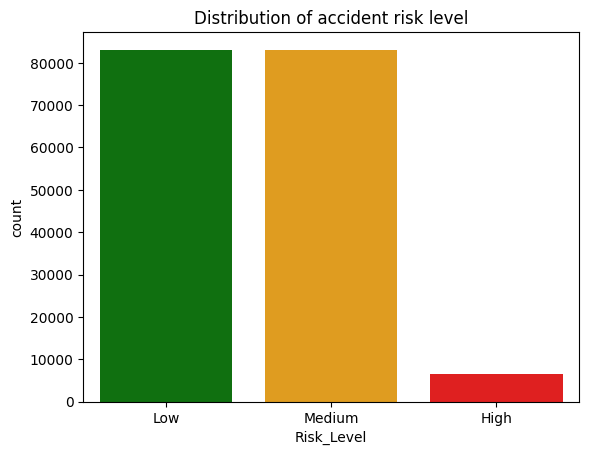

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(
    x="Risk_Level",
    data=test,
    palette={"Low": "green", "Medium": "orange", "High": "red"}
)

plt.title("Distribution of accident risk level")